In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from narwhals.selectors import categorical
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

In [71]:
application_train = pd.read_csv("train_features.csv")
application_test = pd.read_csv("test_features.csv")

In [72]:
application_train.shape

(307511, 169)

In [73]:
application_test.shape

(48744, 168)

In [74]:
application_train.head()

,Unnamed: 0,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,max_amt_application,mean_amt_credit,max_amt_credit,mean_percentage_recieved,mean_amt_down_payment,max_amt__down_payment,prev_application_count,prev_approved,prev_refused,prev_approval_rate
0,0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,...,179055.0,179055.00,179055.0,0.999994,0.00,0.0,1.0,1.0,0.0,1.000000
1,1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,...,900000.0,484191.00,1035882.0,1.057658,3442.50,6885.0,3.0,3.0,0.0,1.000000
2,2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,...,24282.0,20106.00,20106.0,0.827987,4860.00,4860.0,1.0,1.0,0.0,1.000000
3,3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,...,688500.0,291695.50,906615.0,0.675118,34840.17,66987.0,9.0,5.0,1.0,0.555556
4,4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,...,247500.0,166638.75,284400.0,1.046339,3390.75,3676.5,6.0,6.0,0.0,1.000000


In [75]:
application_test.head()

,Unnamed: 0,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,max_amt_application,mean_amt_credit,max_amt_credit,mean_percentage_recieved,mean_amt_down_payment,max_amt__down_payment,prev_application_count,prev_approved,prev_refused,prev_approval_rate
0,0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,...,24835.5,23787.000,23787.0,0.957744,2520.0,2520.0,1.0,1.0,0.0,1.00
1,1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,...,44617.5,20076.750,40153.5,0.449965,4464.0,4464.0,2.0,1.0,0.0,0.50
2,2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,...,450000.0,146134.125,512370.0,0.789255,3375.0,6750.0,4.0,3.0,0.0,0.75
3,3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,...,130765.5,92920.500,225000.0,45000.580479,3750.0,11250.0,5.0,3.0,0.0,0.60
4,4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,...,454500.0,300550.500,508495.5,1.131349,8095.5,8095.5,2.0,1.0,0.0,0.50


In [76]:
application_train.drop(columns=["Unnamed: 0"], inplace=True)
application_test.drop(columns=["Unnamed: 0"], inplace=True)

In [77]:
y = application_train["TARGET"]
X = application_train.drop("TARGET", axis=1)

In [78]:
numerical_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(exclude="number").columns.tolist()

In [79]:
print(len(numerical_cols))
print(len(categorical_cols))

151
16


In [80]:
categorical_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [81]:
for col in categorical_cols:
    X[col] = X[col].astype('category')
    application_test[col] = application_test[col].astype('category')

In [82]:
import re
[col for col in X.columns if re.search(r'[^A-Za-z0-9_]', col)]

[]

In [83]:
X.dtypes[X.dtypes == 'object']

Series([], dtype: object)

In [84]:
#Probieren wir es zuerst mit einem LightGBM

In [85]:
GBM = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31
)
GBM.fit(X, y)

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19880
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 163
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [86]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(GBM, X, y, cv=cv, n_jobs=-1, scoring="roc_auc")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19866
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 162
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.174670 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19818
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 163
[L

In [87]:
scores.mean()
#Output: 0.7758985820151467

np.float64(0.7758985820151467)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

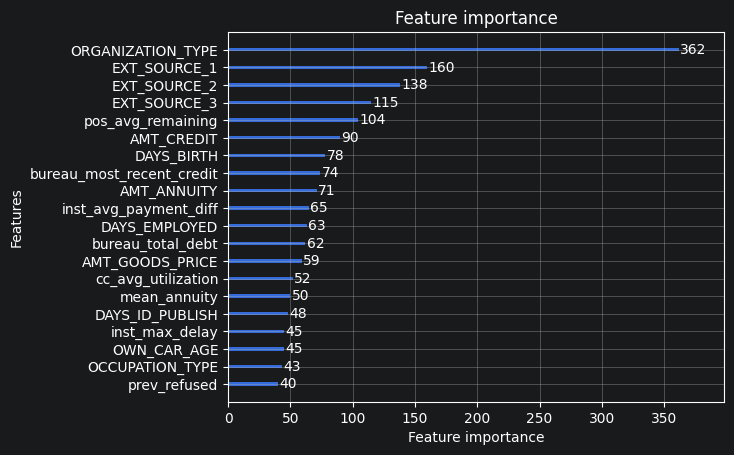

In [88]:
lgb.plot_importance(GBM, max_num_features=20)

In [89]:
X_test = application_test.copy()
predictions = GBM.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeit für Klasse 1

# Submission erstellen
submission = pd.DataFrame({
    "SK_ID_CURR": application_test["SK_ID_CURR"],
    "TARGET": predictions
})
submission.to_csv("submission1.csv", index=False)